In [3]:
#basic libs
import os, gc, json, sys, glob, pymp
from pathlib import Path
sys.path.append('/media/jobueno/STOV/scripts/')
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import RegularGridInterpolator

import numpy as np
import pandas as pd
import xarray as xr
from xarray import DataTree, register_datatree_accessor

#Vars
_varsTypes = { # Outputs
              'density': np.float16, #smaller float / float
              'pressure': np.float64,
              'heat': np.float64,
              'thermal_difussivity': np.float64,
              'surface': np.float32,
              'lithology': np.int8, #
              'viscosity': np.float64, #
              'velocity': np.float64,
              'strain': np.float64,
              'strain_rate':np.float64,


              # Post processing
              'deviatoric_stress':np.float32, # considers \\tau in MPa
              
              #Dimensions
              'time': np.float32,
              'x': np.float32,
              'z': np.float32,
              'id': np.int64 # for particles
}


'''
int8
range: -128 to 127
size: 1 byte
precision: none

int16
range: -32,768 to 32,767
size: 2 bytes
precision: none

int32
range: -2,147,483,648 to 2,147,483,647 (-2^31 to 2^31 - 1)
size: 4 bytes
precision: none

int64
range: -9.22e18 to 9.22e18 (-2^63 to 2^63 - 1)
size: 8 bytes
precision: none

uint8
range: 0 to 255
size: 1 byte
precision: none

uint16
range: 0 to 65,535
size: 2 bytes
precision: none

float16
range: -65,504 to +65,504
size: 2 bytes
precision: ~3 decimal digits

float32
range: -3.4e38 to +3.4e38
size: 4 bytes
precision: ~7 decimal digits

float64
range: -1.79e308 to +1.79e308
size: 8 bytes
precision: ~15 to 17 decimal digits
'''


_variables = ["density",
"heat",
"strain",
"lithology",
"strain_rate",
"surface",
"pressure",
"temperature",
"thermal_diffusivity",
"velocity",
"viscosity",
"surface"]

In [45]:
#Mandyoc Scenario class
class MandyocScen:
    
    def __init__(self, path, variables=['density'], name=None,
                 load_lithology=False, load_surface=False, load_particles=False,
                 particles_file='particles_trajectories.nc',
                 xlimits=None, zlimits=None, tlimits=None, # ylimits should be implemented for the 3D version
                 thick_air=40e3,
                 chunks_vars={"x": 'auto', "z": 'auto', 'time': "auto"},
                 filter_air=True, #only relevant if load particles
                 verbose=False):

        # Setting directories and scen name
        self.path = Path(path)
        self.verbose = verbose
        if isinstance(name, str): self.name = name
        else: self.name = self.path.name

        if self.verbose:
            print(f'Scenario at: {self.path}')
            print(f'Scenario name: {self.name}')
        
        # Handle Variables and Extract Metadata
        if isinstance(variables, str): variables = [variables]
        elif not isinstance(variables, (list, tuple, np.ndarray)): variables = list(variables)
        
        if len(variables) == 0:
            raise ValueError("The 'variables' list cannot be empty. Need at least one variable to extract metadata.")
        
        self.get_scenarioData(variables[0])
        
        self.xlimits = xlimits if xlimits is not None else [self.XMIN, self.XMAX]
        self.zlimits = zlimits if zlimits is not None else [self.ZMIN, self.ZMAX]
        self.tlimits = tlimits if tlimits is not None else [self.TMIN, self.TMAX]
        self.thick_air = thick_air #m

        if self.verbose:
            print(f'x limits: {self.xlimits}')
            print(f'z limits: {self.zlimits}')
            print(f'time limits: {self.tlimits}')
        
        self.z_corrected = False
        self.particles_load = False
        
        # Initialize the empty DataTree
        self.DTree = DataTree()

        # Passing some metadata to the DataTree
        self.DTree.attrs['name'] = self.name
        self.DTree.attrs['xlimits'] = self.xlimits
        self.DTree.attrs['zlimits'] = self.zlimits
        self.DTree.attrs['tlimits'] = self.tlimits
        
        # Reading and storing standard variables (Nx,Nz)
        standard_datasets = []
        for var in variables:
            ds = self._load_spatial_var(var, chunks=chunks_vars)
            if ds is not None:
                standard_datasets.append(ds)
        
        if standard_datasets:
            self.DTree['/mesh/original'] = xr.merge(standard_datasets)

        if self.verbose: print(f"Variables loaded: {' '.join(variables)}")
        
        # Reading and storing the lithology (upscaled mesh)
        if load_lithology==True:
            ds_litho = self._load_spatial_var('lithology', chunks=chunks_vars)
            if ds_litho is not None:
                self.DTree['/mesh/upscaled'] = ds_litho

        if self.verbose: print("Lithology loaded")
            
        # Reading the surface/topography (only X dimension)
        if load_surface==True:
            
            ds_surf = self._load_spatial_var('surface', chunks=chunks_vars)
            if ds_surf is not None:
                self.DTree['/surface/topography'] = ds_surf

        if self.verbose: print("Surface loaded")
            
        # Loading particles
        if load_particles:
            self._load_particles(particles_file, chunks={'id': 'auto'}, filter_air=True)
            
        if self.verbose: print(f"Particles [{particles_file}] loaded")
            
        #self.original_particles = None   #whole particles dataset (can be replaced for subsets)
        self.selected_particles = None   #current selected particles
        self.particles = {}  #dictionary with particle selections
        
        return None
    
    def get_scenarioData(self, var='density'):
        file_path = self.path / f"{var}.nc"
            
        if not file_path.exists():
            raise FileNotFoundError(f"Cannot extract metadata. File not found: {file_path}")

        # Open lazily and safely close automatically using 'with'
        with xr.open_dataset(file_path) as ds:
            # Getting dimensions, maximum and minimum from a base netcdf
            self.Nx = ds.sizes['x']
            self.Nz = ds.sizes['z']
                        
            self.XMAX = ds.x.max().item()
            self.XMIN = ds.x.min().item()
            self.ZMAX = ds.z.max().item()
            self.ZMIN = ds.z.min().item()
            self.TMAX = ds.time.max().item()
            self.TMIN = ds.time.min().item()

        return True
    
    def correctZcoord(self, factor=None):
        if self.z_corrected:
            if self.verbose: print("Z was already corrected")
            return False
        
        if factor is None:
            factor = self.ZMAX - self.thick_air
        
        # Traverse specific tree nodes and apply Z-correction if 'z' exists
        structs_to_check = ['/mesh', '/surface','/particles']
        
        mesh_nodes = list(self.DTree['/mesh'].children) # Mesh data (Eulerian grids)
        surface_nodes = list(self.DTree['/surface'].children) # Surface/string data (only X dimension)
        particles_nodes = list(self.DTree['/particles'].children) # Lagrangian particles 
        
        for node in mesh_nodes:
            node_ds = self.DTree['/mesh'][node].ds
            self.DTree['/mesh'][node] = node_ds.assign_coords(z=(node_ds['z'] - factor))
        
        for node in surface_nodes:    #O script em julia está exportando com a superfície corrigida, mudar para exportar com o dado ORIGINAL
            node_ds = self.DTree['/surface'][node].ds
            self.DTree['/surface'][node] = node_ds.assign(surface=(node_ds['surface'] - factor))

        for node in particles_nodes:
            node_ds = self.DTree['/particles'][node].ds
            self.DTree['/particles'][node] = node_ds.assign(z=(node_ds['z'] - factor))

        self.zlimits = [self.zlimits[0] - factor, self.zlimits[1] - factor]
        self.ZMAX -= factor
        self.ZMIN -= factor
        
        if self.verbose:
            print(f"Z coordinate corrected by subtracting {factor} m")
            print(f"New z limits: {self.zlimits}")
            
        self.z_corrected = True
        return True

    def _load_spatial_var(self, variable, chunks={}):
        """
        Internal function to load Eulerian grids and slice them to xlimits,zlimits
        """
        
        file_path = self.path / f"{variable}.nc"
        
        if not file_path.exists():
            print(f"Warning: {file_path} not found. Skipping.")
            return None
            
        v = xr.open_dataset(file_path, chunks=chunks)
        
        if 'z' in v.coords:
            v = v.sortby('z')
            v = v.sel(
                x=slice(self.xlimits[0], self.xlimits[-1]),
                z=slice(self.zlimits[0], self.zlimits[-1]),
                time=slice(self.tlimits[0], self.tlimits[-1])
            )
        else:
            # Surface or 2D variables
            v = v.sel(x=slice(self.xlimits[0], self.xlimits[-1]),
                     time=slice(self.tlimits[0], self.tlimits[-1]))
            
        return v
    
    def _load_particles(self, name, chunks={'id': 'auto'}, filter_air=True, air_layer=None):
        """
        Internal function to load particles dataset 
        """        
        file_path = self.path / name
        
        if not file_path.exists():
            print(f"Warning: Particles file {file_path} not found. Skipping.")
            return False
            
        particles = xr.open_dataset(file_path, chunks=chunks)
        particles = particles.sel(time=slice(self.tlimits[0], self.tlimits[-1]))
        
        if filter_air and 'layer' in particles.data_vars:
            if isinstance(air_layer, int): air = air_layer
            else: air = int(particles.layer.max())
                
            cond = particles != air
            particles = particles.where(cond)
            
        self.DTree['/particles/original'] = particles
        return True
    
    
    def _apply_selection(self, valid_ids, replace_original=True, selected_name='',
                                    selection_name=''):
        """
        Internal function to select a dataset by the IDs
        """
        
        if replace_original==True:
            selection_name = 'original'
        elif selection_name == '':
            selection_name == 'selected'
        
        source_ds = self.DTree.particles[selected_name].ds
    
        self.DTree.particles[selection_name] = source_ds.sel(id=valid_ids)
    
        gc.collect()
        return None

    def _get_pts(self, select_original=True, selected_name=''):
        if select_original==True: selected_name = 'original'
        elif selected_name == '': selected_name = 'selected'
        pts = self.DTree.particles[selected_name].ds
        return pts, selected_name
    
    #Selecting particles
    def selectParticles_bytimerange(self, timerange, select_original=True, selected_name='',
                                    selection_name='', replace_original=False):
        '''
        select particles that appeared (e.g. sedimented) within the specified time range
        timerange : array-like = [tmin, tmax]
        '''
        # apply the support selection function
        pts, selected_name = self._get_pts(select_original, selected_name)
        
        # get IDs of the time "i" and time "0"
        tr_0 = pts.sel(time=timerange[0],method='nearest').dropna(dim="id").id.values
        tr_i = pts.sel(time=timerange[1],method='nearest').dropna(dim="id").id.values

        # get the difference between them (using sets)
        ids = list(set(tr_i)-set(tr_0))
        
        # apply the support selection function
        self._apply_selection(ids, 
                              selected_name=selected_name, 
                              replace_original=replace_original, 
                              selection_name=selection_name)
        return self
        
    
    def selectParticles_bycoords(self, xlim=None, ylim=None, tsel=None, 
                                 select_original=True,selected_name='',selection_name='',replace_original=False):
        '''
        coords : list = [[xmin, xmax],[ymin,ymax]]
        '''
        
        if xlim is None: xlim = self.xlimits
        if ylim is None: ylim = self.zlimits

        pts, selected_name = self._get_pts(select_original, selected_name)
            
        if tsel is None: tsel = 0
        
        pts = pts.sel(time=tsel, method='nearest')
        condX = ((pts["x"] >= xlim[0]) & (pts["x"] <= xlim[1])).compute()
        pts =  pts.where(condX, drop=True)
        
        condZ = ((pts["z"] >= ylim[0]) & (pts["z"] <= ylim[1])).compute()
        pts =  pts.where(condZ, drop=True)
        ids = pts.id.values
              
        # apply the support selection function
        self._apply_selection(ids, 
                              selected_name=selected_name, 
                              replace_original=replace_original, 
                              selection_name=selection_name)
        
        return self
    
    
    def selectParticles_bylayers(self, layers, tsel=None, 
                                select_original=True,selected_name='',selection_name='',replace_original=False):
        '''
        select particles by layer
        '''
        
        pts, selected_name = self._get_pts(select_original, selected_name)
        if tsel is None: tsel = 0 # Future: to create a function to evaluate an automatic tsel
        
        pts = pts.sel(time=tsel, method='nearest')
        cond = pts.layer.isin(layers).compute()
        ids =  pts.id.where(cond, drop=True).values
        
        self._apply_selection(ids, 
                              selected_name=selected_name, 
                              replace_original=replace_original, 
                              selection_name=selection_name)
        return self
    
    
    def classify_ParticlesRange(self, domain_intervals, tsel=None,
                               select_original=True,selected_name='',selection_name='',replace_original=False):
        
        #Classify all particles based on X ranges, given a time step tsel
        #Categories are based on the domain intervals keys
        
        pts, selected_name = self._get_pts(select_original, selected_name)
        
        if replace_original==True:
            selection_name = 'original'
        elif selection_name == '':
            selection_name == 'selected'
        
        if tsel is None: tsel = 0
        
        domain_intervals = domain_intervals.copy()
        
        try: field_name = domain_intervals['field_name']
        except: field_name = 'domain'
        del domain_intervals['field_name']
        
        typename = type(list(domain_intervals.keys())[1])
        if typename is str: typename='U256'
        
        if field_name in pts:
            print(f"{field_name} is a dataset variable, choose another name")
            return False
        
        pts[field_name] = (['id'], np.full(pts.sizes['id'], '', dtype=typename))
        
        snapshot = pts.sel(time=tsel, method='nearest')
        
        for dom, intervals in list(domain_intervals.items()):
            
            if not isinstance(intervals[0], (list, tuple, np.ndarray)): intervals = [intervals]
            mask_combined = np.zeros(snapshot.sizes['id'], dtype=bool)
            
            for start, end in intervals:
                mask_current = ((snapshot.x >= start) & (snapshot.x <= end)).compute()
                mask_combined |= mask_current.values
            
            ids_in_domain = snapshot.id.values[mask_combined]
            pts[field_name] = xr.where(pts.id.isin(ids_in_domain), dom,  pts[field_name])
        
        self.DTree.particles[selection_name] = pts
        
        pts[field_name].attrs['reference timestep'] = f'{tsel}myr'
        pts[field_name].attrs['classes range'] = str(domain_intervals)
        gc.collect()
        
        return self

    def fieldToParticle(self, variable, 
                       select_original=True,selected_name='',selection_name='',replace_original=False):
        
        pts0, selected_name = self._get_pts(select_original, selected_name)

        if replace_original==True:
            selection_name = 'original'
        elif selection_name == '':
            selection_name == 'selected'
        
        field = self.vars_DS[variable]
        #if not isinstance(variables, (list, tuple, np.ndarray)): variables = [variable]
        
        pts = pts0.copy()
        
        components = list(field.data_vars)
        
        field_interpolated = field.interp(
            x=pts.x, 
            z=pts.z, 
            method='linear'
        )
        
        for comp in components:
            #print('comp')
            #print(field_interpolated[comp])
            pts[comp] = field_interpolated[comp].drop_vars(['x', 'z']).transpose('id', 'time') #did it worked?
            # pts[comp] = (['id', 'time'], field_interpolated[comp].data)
        
        
        self.DTree.particles[selection_name] = pts

        gc.collect()
        return self
        

In [9]:
class mandyocPlotter: #função para receber os dados de um cenario e fazer plots
    
    def __init__(self, mandyocScen, 
                 cmap_dir='/media/jobueno/STOV/scripts/salt_cmap.json'):
        
        return self
    
        
    def read_cmap(self, cmap_dir):
        json_dir = cmap_dir
        file = open(json_dir,"r")
        cmap_json = json.load(file)
        self.cmap_metadata = cmap_json['metadata']
        self.cmap = LinearSegmentedColormap.from_list(name=self.cmap_metadata['name'], 
                                                      colors=cmap_json['colors'], 
                                                      N=cmap_json['metadata']['N_layers'])
        #plt.register_cmap(name=cmap_metadata['name'], cmap=cmap_json['colors'])
        file.close()
        return True
    
    class snapshot(): #sub classe de Plotter para plotar os campos/cenarios de 1 step selecionado
        
        def __init__(self, tselect):
        
            
            return self

In [10]:
@register_datatree_accessor("postproc")
class scenPostProcessing:

    def __init__(self, mandyocScen_DTree, varsTypes=_varsTypes):
        '''
        It is a class to calculate common post-processing variables on a loaded scenario
        '''
        
        self.scenario = mandyocScen_DTree
        self.varsTypes = varsTypes
        
        return None
    
    def StressTensor(self, components='all', J2=True, mesh_upscaled=False,
                    units='MPa', export_nc=False):
        '''
        Calculates the deviatoric stress tensor and second invariant (J2).
        Optimized for incompressible fluids (div(v) = 0).
        
        Signal convention:
           Positive: extension
           Negative: compression


        ---
        
        This function calculate the deviatoric stress tensor (\\tau or \\sigma') through the relation:
           $ \\tau_{ij} = 2 d \\epsilon_{ij} \\dt * \\nu $
        where ij are the coodinates components, d \\epsilon \\dt is the strain rate, and \nu is the viscosity.
        
        The strain rate is calculate using the velocity field (v_{ij}) by:
            d \\epsilon_{ij} \\dt = 1/2 (dv_{i}/dx_{j} + dv_{j}/dx_{i}) 
        
        ---

        components -> future improvement: to calculate only the desired components (useful for the 3D version)
        mesh_upscaled -> future improvement: to use a upscaled field rather than the original mesh
        export_nc -> to export the deviatoric stress tensor as a NETCDF4 file
        '''

        dtype = self.varsTypes['deviatoric_stress']
        tau_factor = 1.0
        if units == 'MPa':
            tau_factor = 1e6

        
        scen = self.scenario
        mesh = scen.mesh['original'].to_dataset()

        vx = mesh['vx']
        vz = mesh['vy'] # current export uses vy instead vz, it must be rewrite for the 3D version
        visc = mesh['viscosity']

        # calculate the strain tensor components
        dvx_dx = vx.differentiate('x',edge_order=2)
        dvx_dz = vx.differentiate('z',edge_order=2)   #\\tau_{xz} = \\tau_{zx} 
        dvz_dx = vz.differentiate('x', edge_order=2)

        # calculate the deviatoric stress tensor components 
        self.scenario['/mesh/original']['tau_xx'] = (2 * visc * dvx_dx / tau_factor).astype(dtype)
        self.scenario['/mesh/original']['tau_zz'] = -self.scenario['/mesh/original']['tau_xx'] # considering fluid incompressibility: u_{i,i} = 0
        
        self.scenario['/mesh/original']['tau_xz'] = (visc * (dvx_dz + dvz_dx) / tau_factor).astype(dtype) 

        for comp in ['tau_xx','tau_zz','tau_xz']:
            self.scenario['/mesh/original'][comp].attrs['long_name'] = comp
            self.scenario['/mesh/original'][comp].attrs['units'] = units
            self.scenario['/mesh/original'][comp].attrs['description'] = f'component {comp} of the deviatoric stress tensor'
        
        self.scenario['/mesh/original']['tau_xz'].attrs['note'] = 'tau_xz = tau_zx'
        
        if J2==True:
            self.scenario['/mesh/original']['tau_J2'] = 1/2 * (self.scenario['/mesh/original']['tau_xx']**2 + self.scenario['/mesh/original']['tau_zz']**2) + self.scenario['/mesh/original']['tau_xz']**2
            self.scenario['/mesh/original']['tau_J2'].attrs['units'] = units
            self.scenario['/mesh/original']['tau_J2'].attrs['long_name'] = 'second invariant of the deviatoric stress tensor'
        
        if export_nc:
            pass # Implement xarray to_netcdf here

        
        return self.scenario

# Testing the class

## 1. Creating the Object

In [56]:
#Basic usage:

#Load a scenario with the variables of interest
scen = MandyocScen('/media/jobueno/STOV/new_salt_sys/kp_salt/15km2', name='CS15',
                   variables=['density','temperature','viscosity','velocity','strain'],
                   tlimits=[0,70],
                   load_lithology=True, load_surface=True, load_particles=True,
                  verbose=True)

#Recommended: correct the Z coordinate to match 0 at the initial surface
scen.correctZcoord()


Scenario at: /media/jobueno/STOV/new_salt_sys/kp_salt/15km2
Scenario name: CS15
x limits: [0.0, 1200000.0]
z limits: [0.0, 300000.0]
time limits: [0, 70]
Variables loaded: density temperature viscosity velocity strain
Lithology loaded
Surface loaded


Particles [particles_trajectories.nc] loaded
Z coordinate corrected by subtracting 260000.0 m
New z limits: [-260000.0, 40000.0]


True

In [57]:
# Calculating the stress tensor field
scen.DTree.postproc.StressTensor()
display(scen.DTree)
print(f'DataTree size: {scen.DTree.nbytes/(1024**3):.3f} GB')

<xarray.DataTree>
Group: /
│   Attributes:
│       name:     CS15
│       xlimits:  [0.0, 1200000.0]
│       zlimits:  [0.0, 300000.0]
│       tlimits:  [0, 70]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 555, z: 601, x: 1201)
│   │       Coordinates:
│   │         * time         (time) float32 2kB 0.0 0.2117 0.4234 ... 69.71 69.82 69.92
│   │         * z            (z) float32 2kB -2.6e+05 -2.595e+05 ... 3.95e+04 4e+04
│   │         * x            (x) float32 5kB 0.0 1e+03 2e+03 ... 1.198e+06 1.199e+06 1.2e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           viscosity    (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           vx           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           vy           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           strain       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 555, z: 3001, x: 6001)
│           Coordinates:
│             * time       (time) float32 2kB 0.0 0.2117 0.4234 0.635 ... 69.71 69.82 69.92
│             * z          (z) float32 12kB -2.6e+05 -2.599e+05 ... 3.99e+04 4e+04
│             * x          (x) float32 24kB 0.0 200.0 400.0 ... 1.2e+06 1.2e+06 1.2e+06
│           Data variables:
│               lithology  (time, z, x) int8 10GB dask.array<chunksize=(123, 645, 1287), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 555, x: 60001)
│           Coordinates:
│             * time     (time) float32 2kB 0.0 0.2117 0.4234 0.635 ... 69.71 69.82 69.92
│             * x        (x) float32 240kB 0.0 20.0 40.0 60.0 ... 1.2e+06 1.2e+06 1.2e+06
│           Data variables:
│               surface  (time, x) float32 133MB dask.array<chunksize=(510, 50005), meta=np.ndarray>
└── Group: /particles
    └── Group: /particles/original
            Dimensions:  (id: 336537, time: 555)
            Coordinates:
              * id       (id) int64 3MB 10007 10008 10010 ... 66013602 66016120 66016121
              * time     (time) float64 4kB 0.0 0.2117 0.4234 0.6351 ... 69.71 69.81 69.92
            Data variables:
                x        (id, time) float64 1GB dask.array<chunksize=(192308, 76), meta=np.ndarray>
                z        (id, time) float64 1GB dask.array<chunksize=(192308, 76), meta=np.ndarray>
                layer    (id, time) float32 747MB dask.array<chunksize=(168270, 152), meta=np.ndarray>
            Attributes:
                description:         particle trajectories
                reference timestep:  69.286myr (13700)
                selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
                disclaimers:         some particles can change its layer over time (sedim...
                weak seed:           2

DataTree size: 27.838 GB


### Scenario manipulation and plotting

In [48]:
cs15_tsel = scen.DTree.sel(time=25,method='nearest').sel(x=slice(0e3,1200e3)) # selecting all data at
mesh = cs15_tsel.mesh['original'].ds

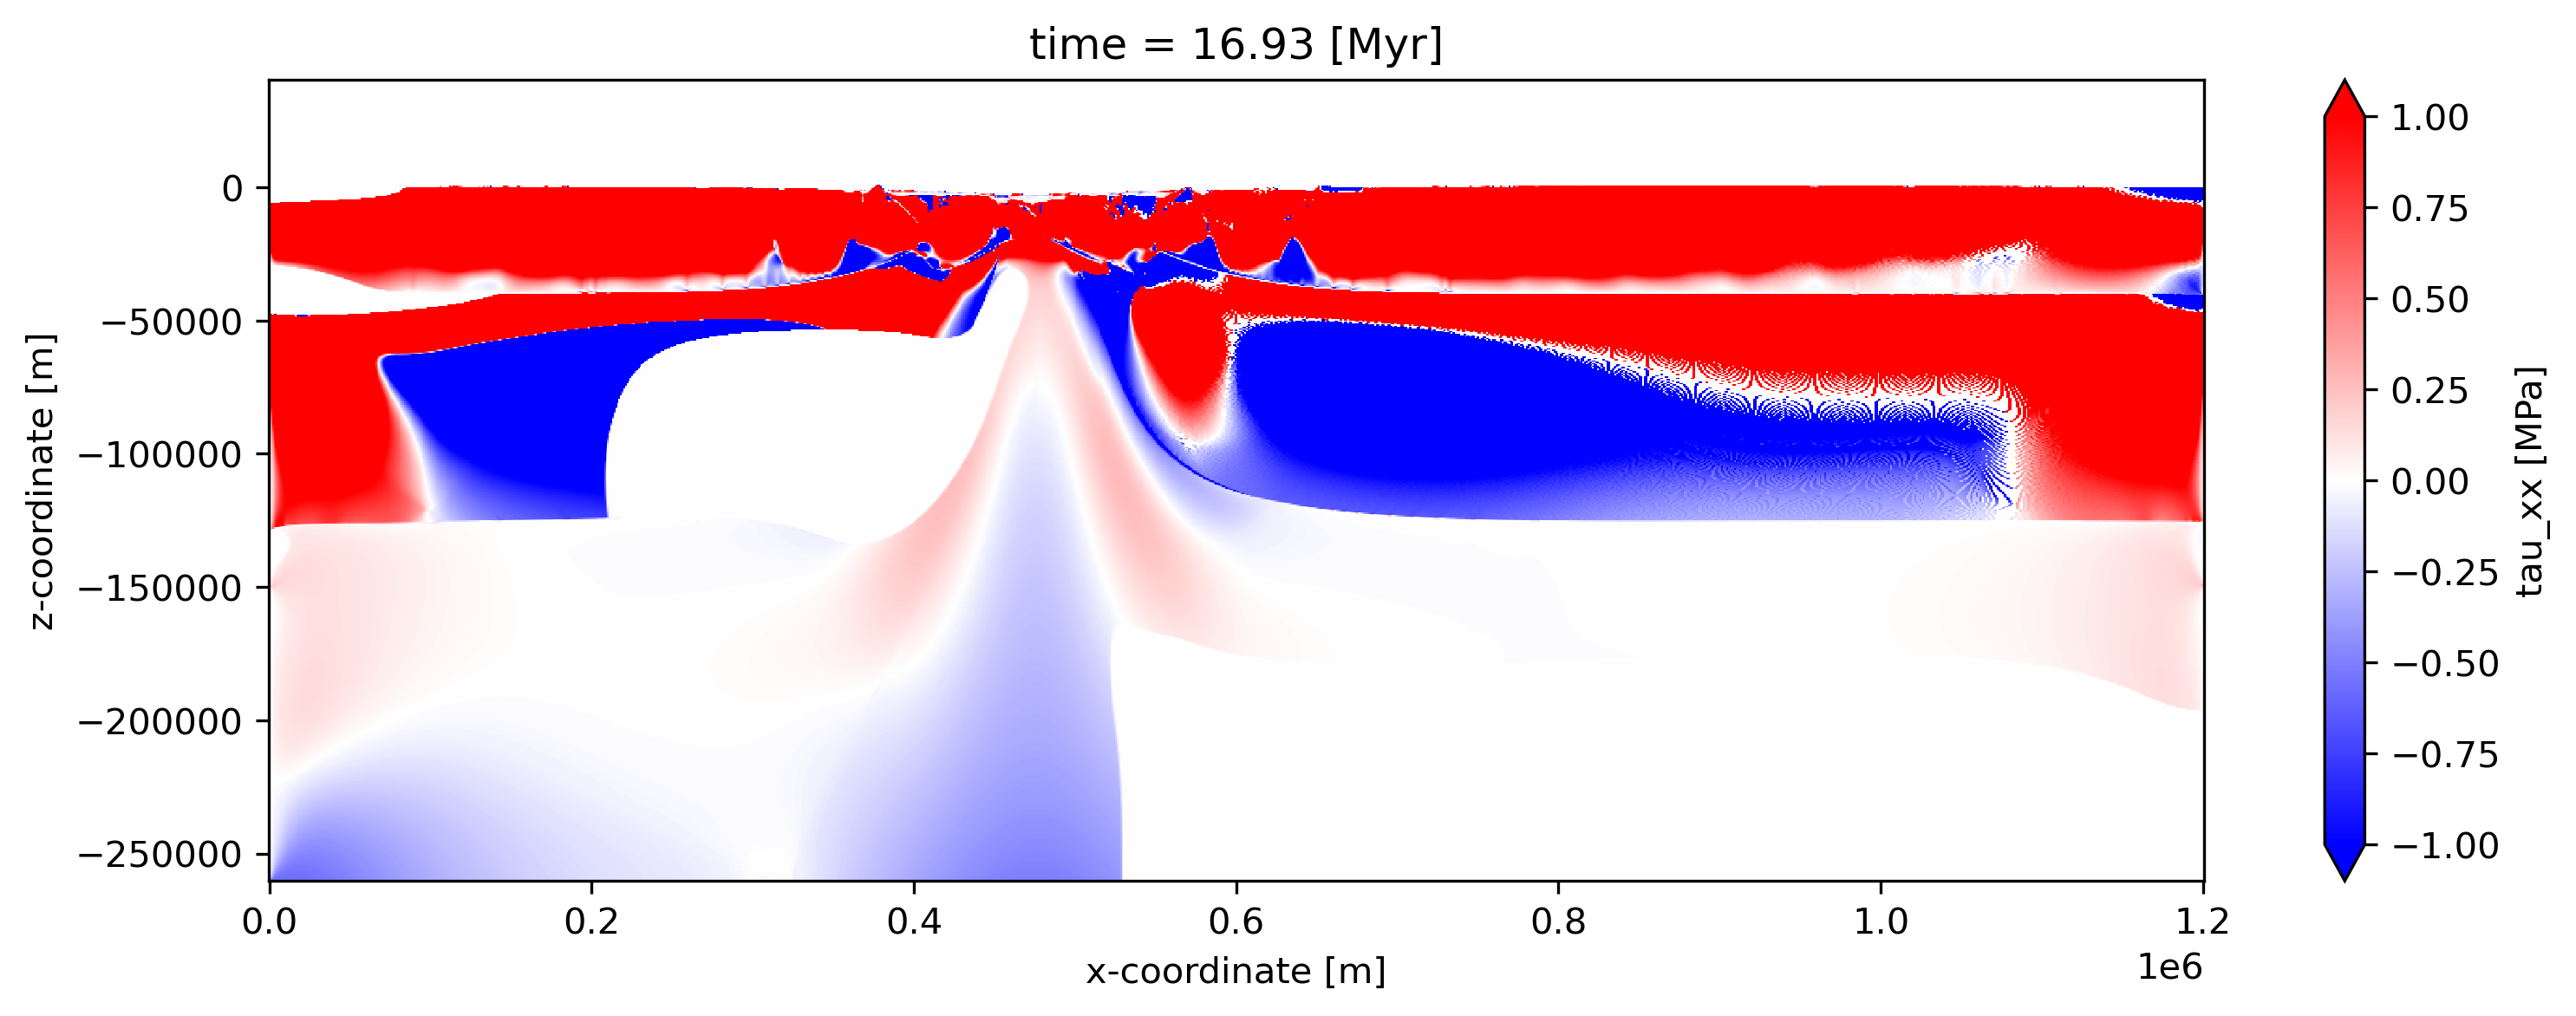

In [47]:
plt.figure(figsize=(12,4),dpi=300)
mesh['tau_xx'].plot.imshow(x='x',y='z', cmap='bwr', vmin=-1,vmax=1)
#plt.ylim(-100e3,5e3)
#mesh['temperature'].plot.contour(x='x',y='z',colors='black',levels=np.linspace(100,1300,7))

/home/jobueno/anaconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)


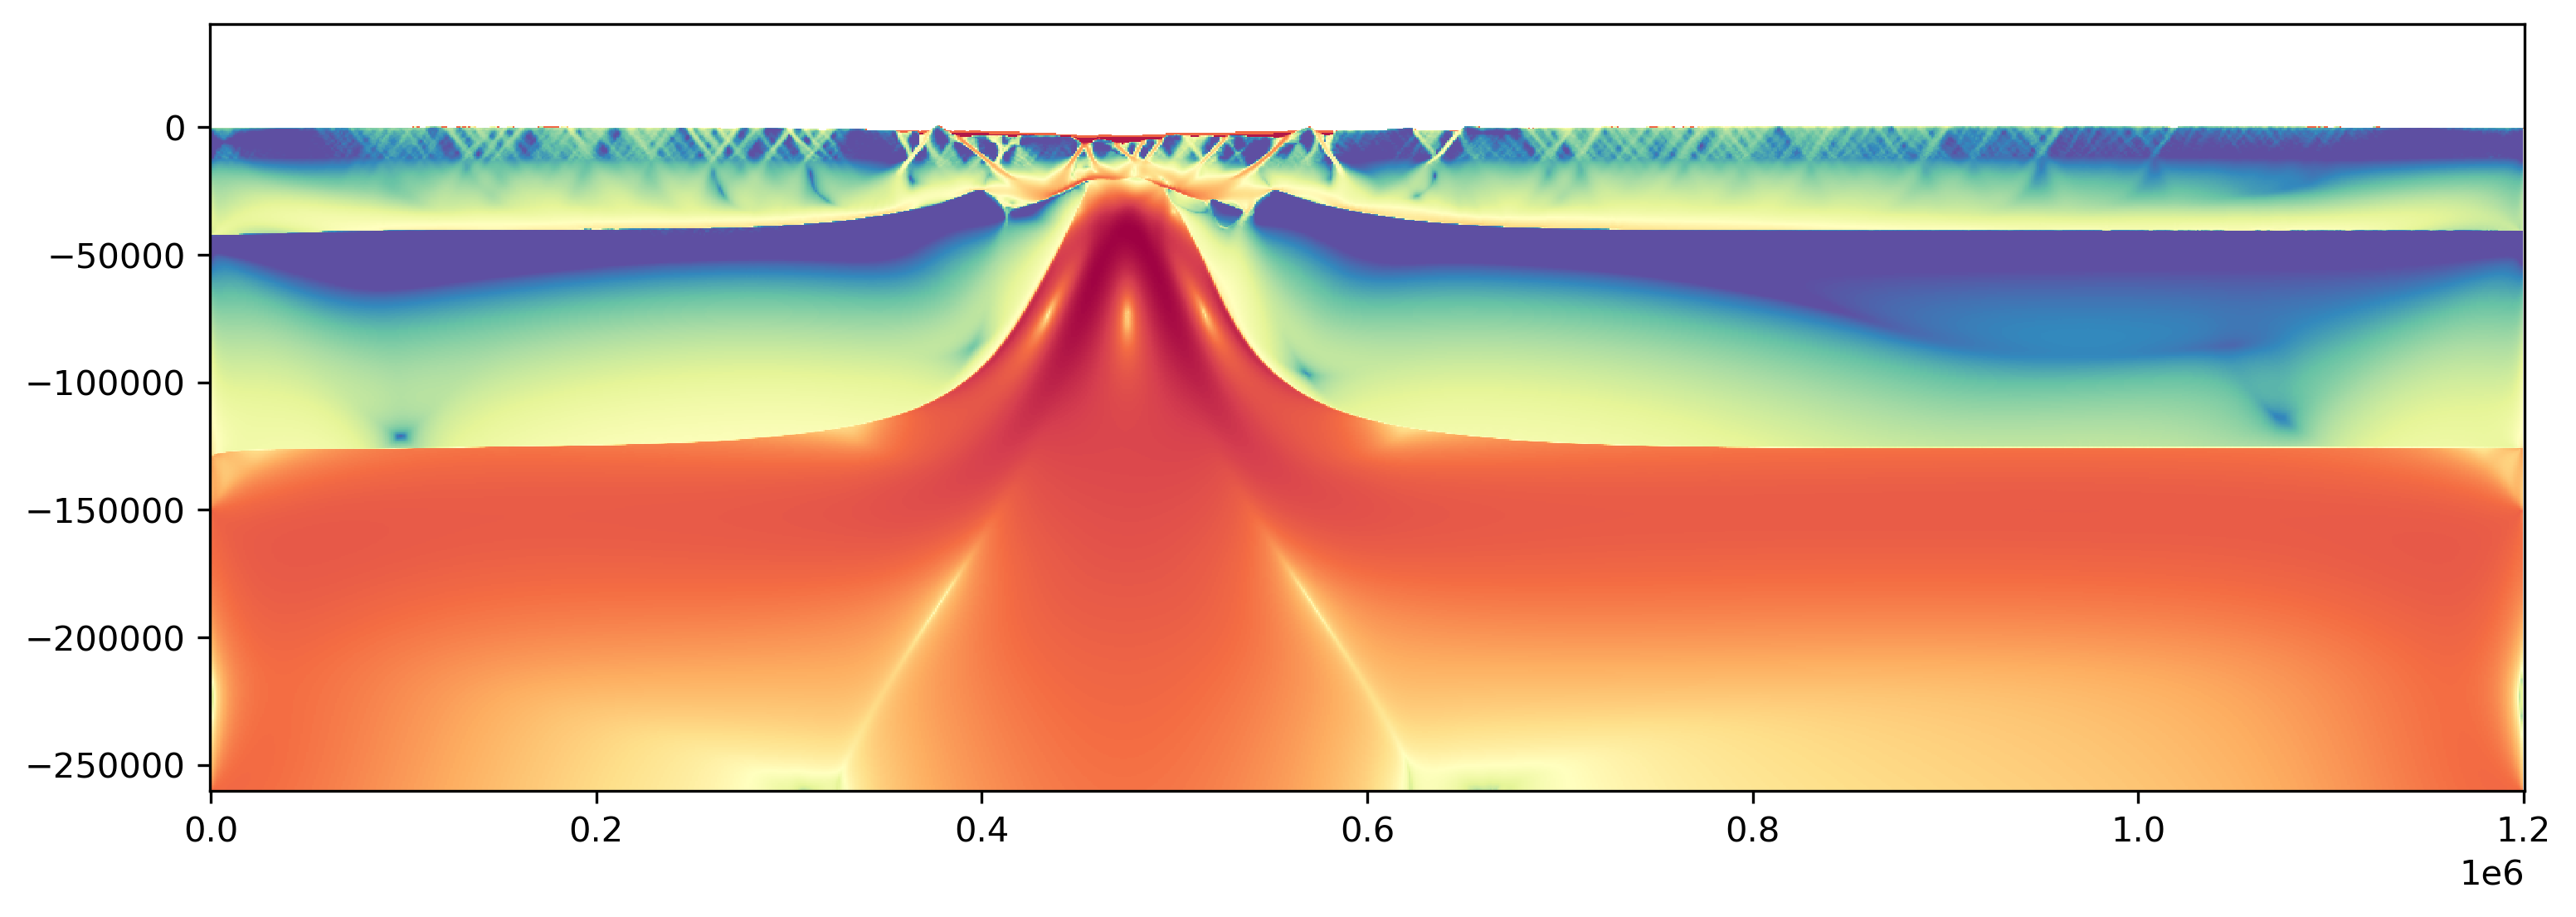

In [48]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(12,4),dpi=300)

visc = mesh['viscosity']
plt.pcolormesh(visc.x,visc.z, np.log10(visc), cmap='Spectral')
# plt.ylim(-100e3,5e3)

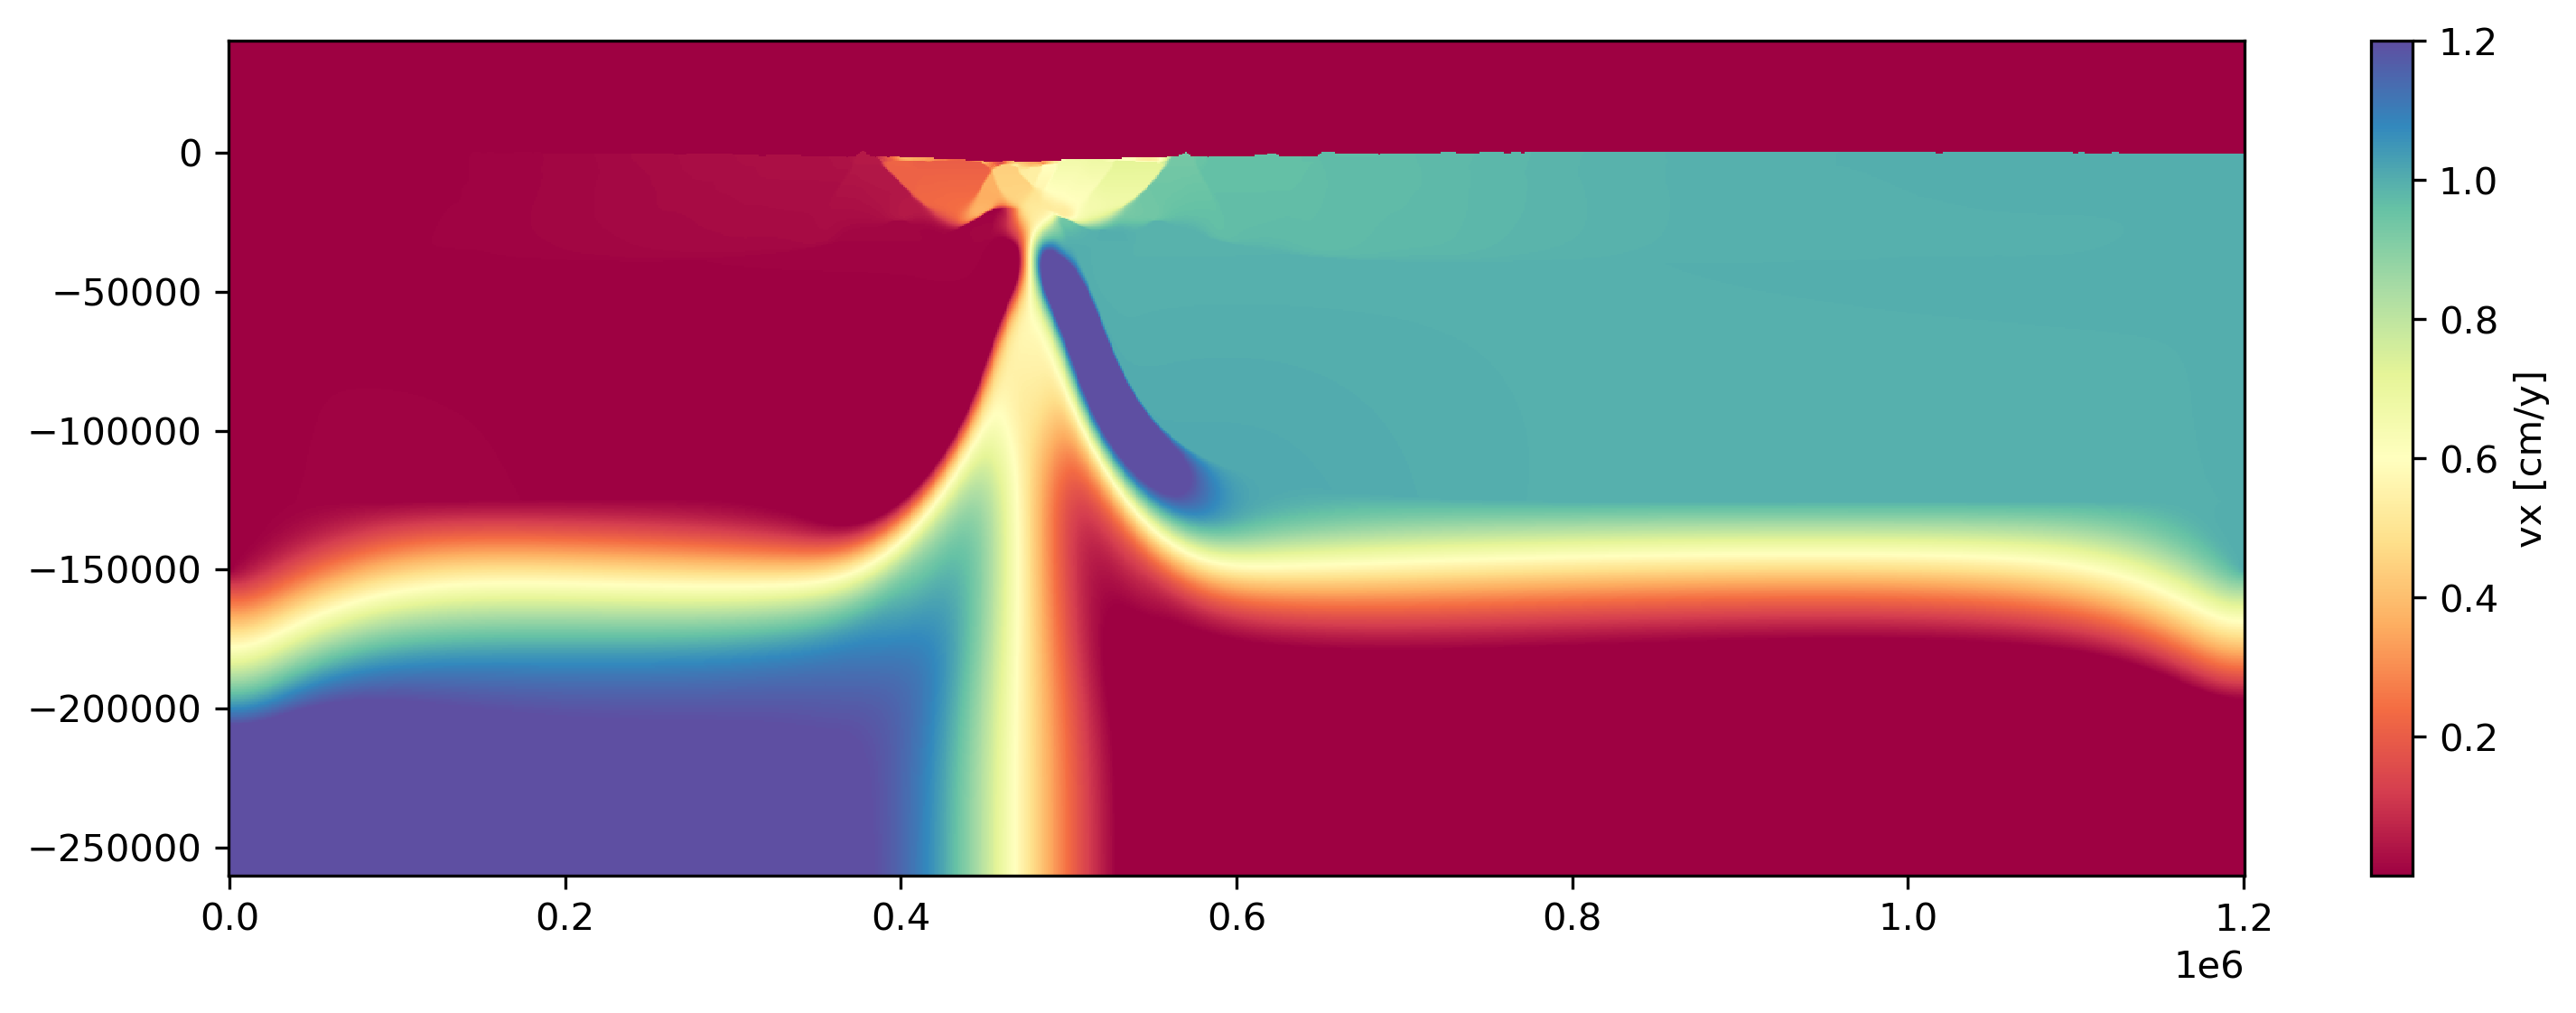

In [53]:
plt.figure(figsize=(12,4),dpi=300)

vx = mesh['vx']
plt.pcolormesh(vx.x,vx.z, vx*(3.156e+9), cmap='Spectral', vmin=1e-4, vmax=1.2)
plt.colorbar(label='vx [cm/y]')
#plt.ylim(-100e3,5e3)

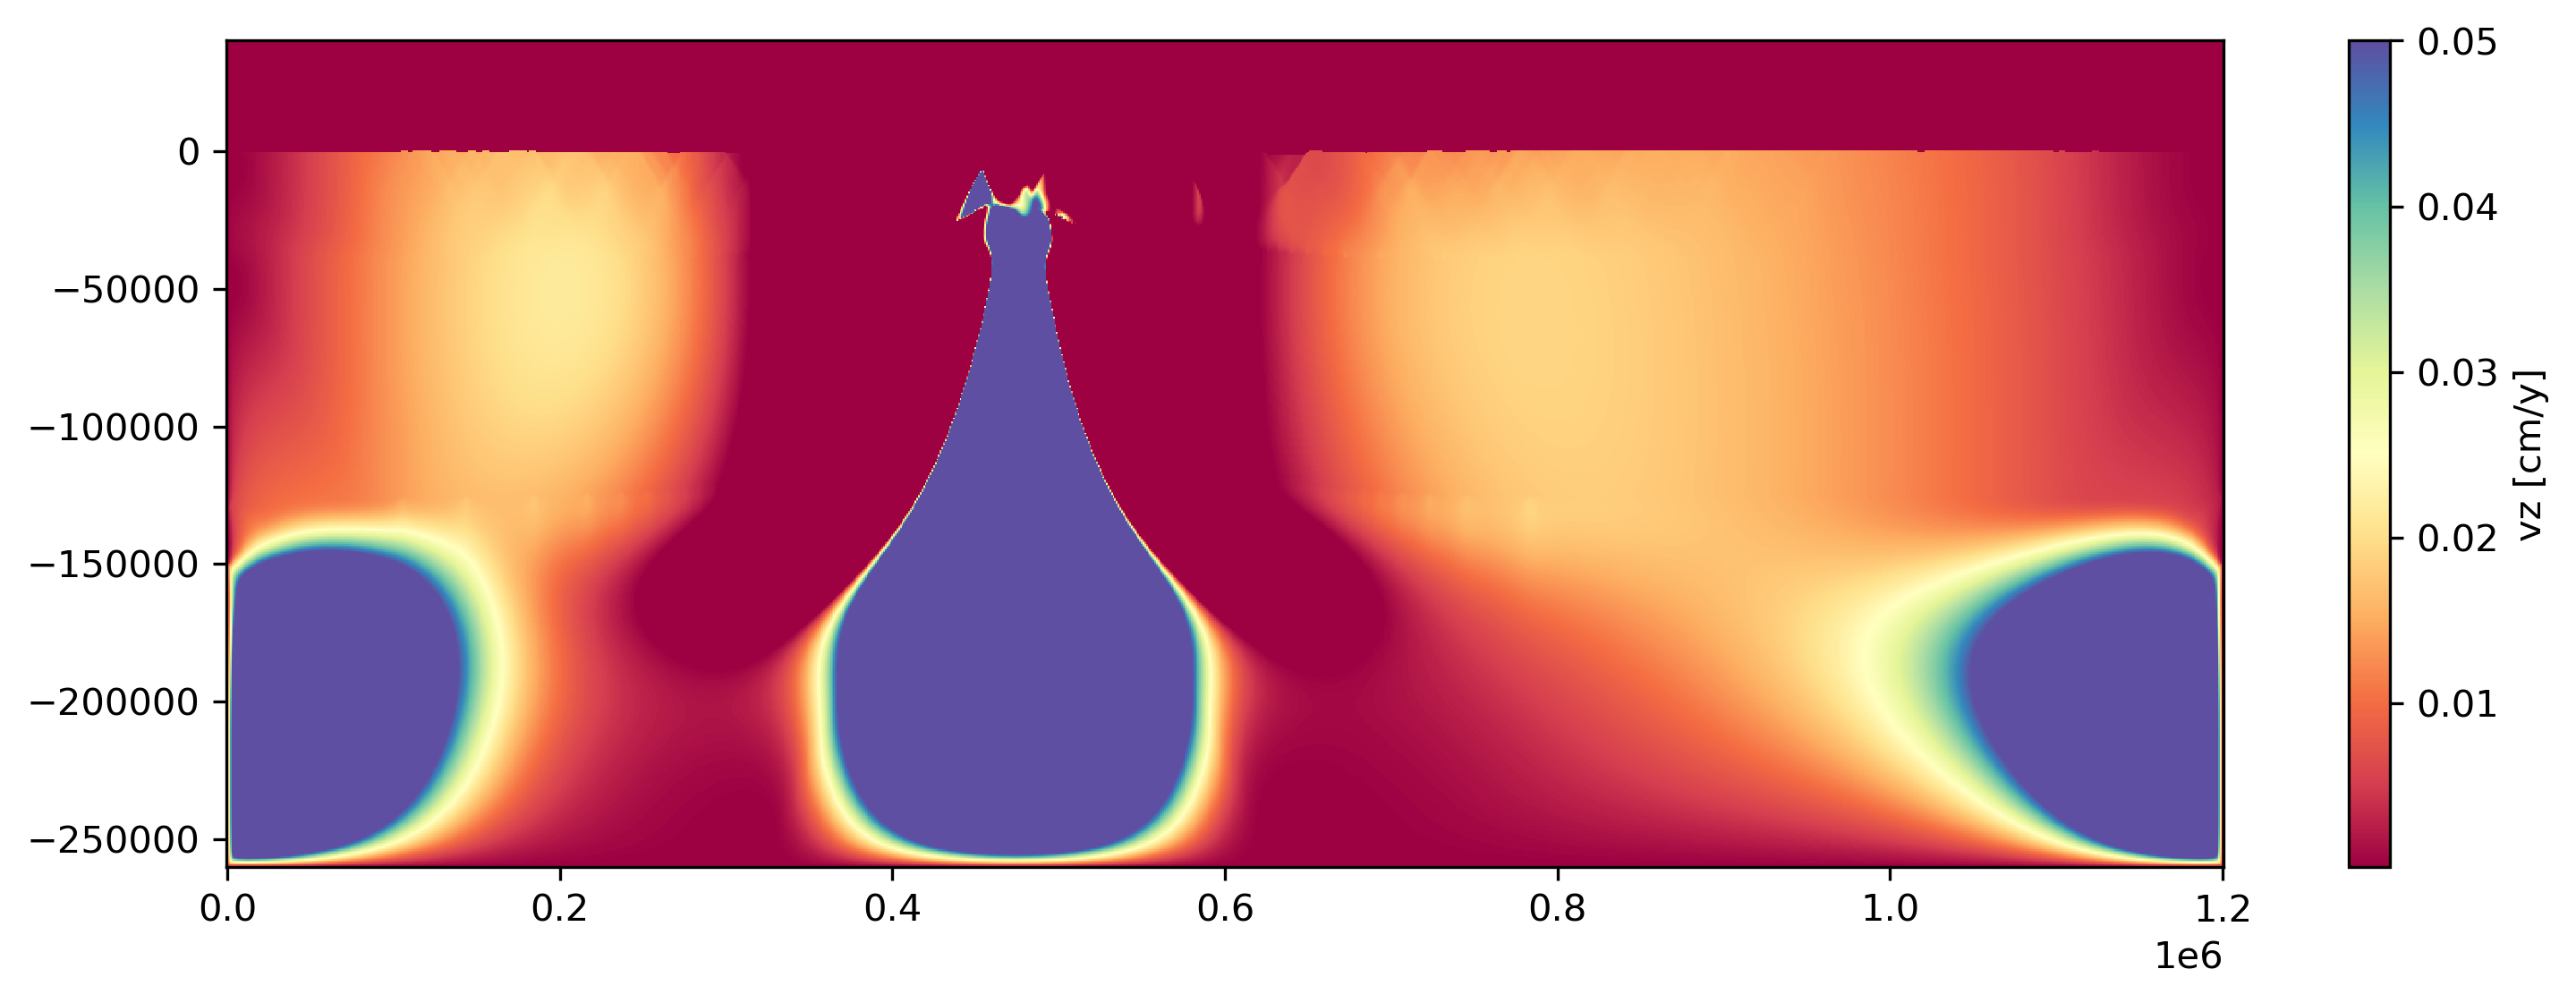

In [50]:
plt.figure(figsize=(12,4),dpi=300)

vz = mesh['vy']
plt.pcolormesh(vz.x,vz.z,vz*(3.156e+9), cmap='Spectral', vmin=1e-4, vmax=0.05)
plt.colorbar(label='vz [cm/y]')
# plt.ylim(-100e3,5e3)

/home/jobueno/anaconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)
/home/jobueno/anaconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


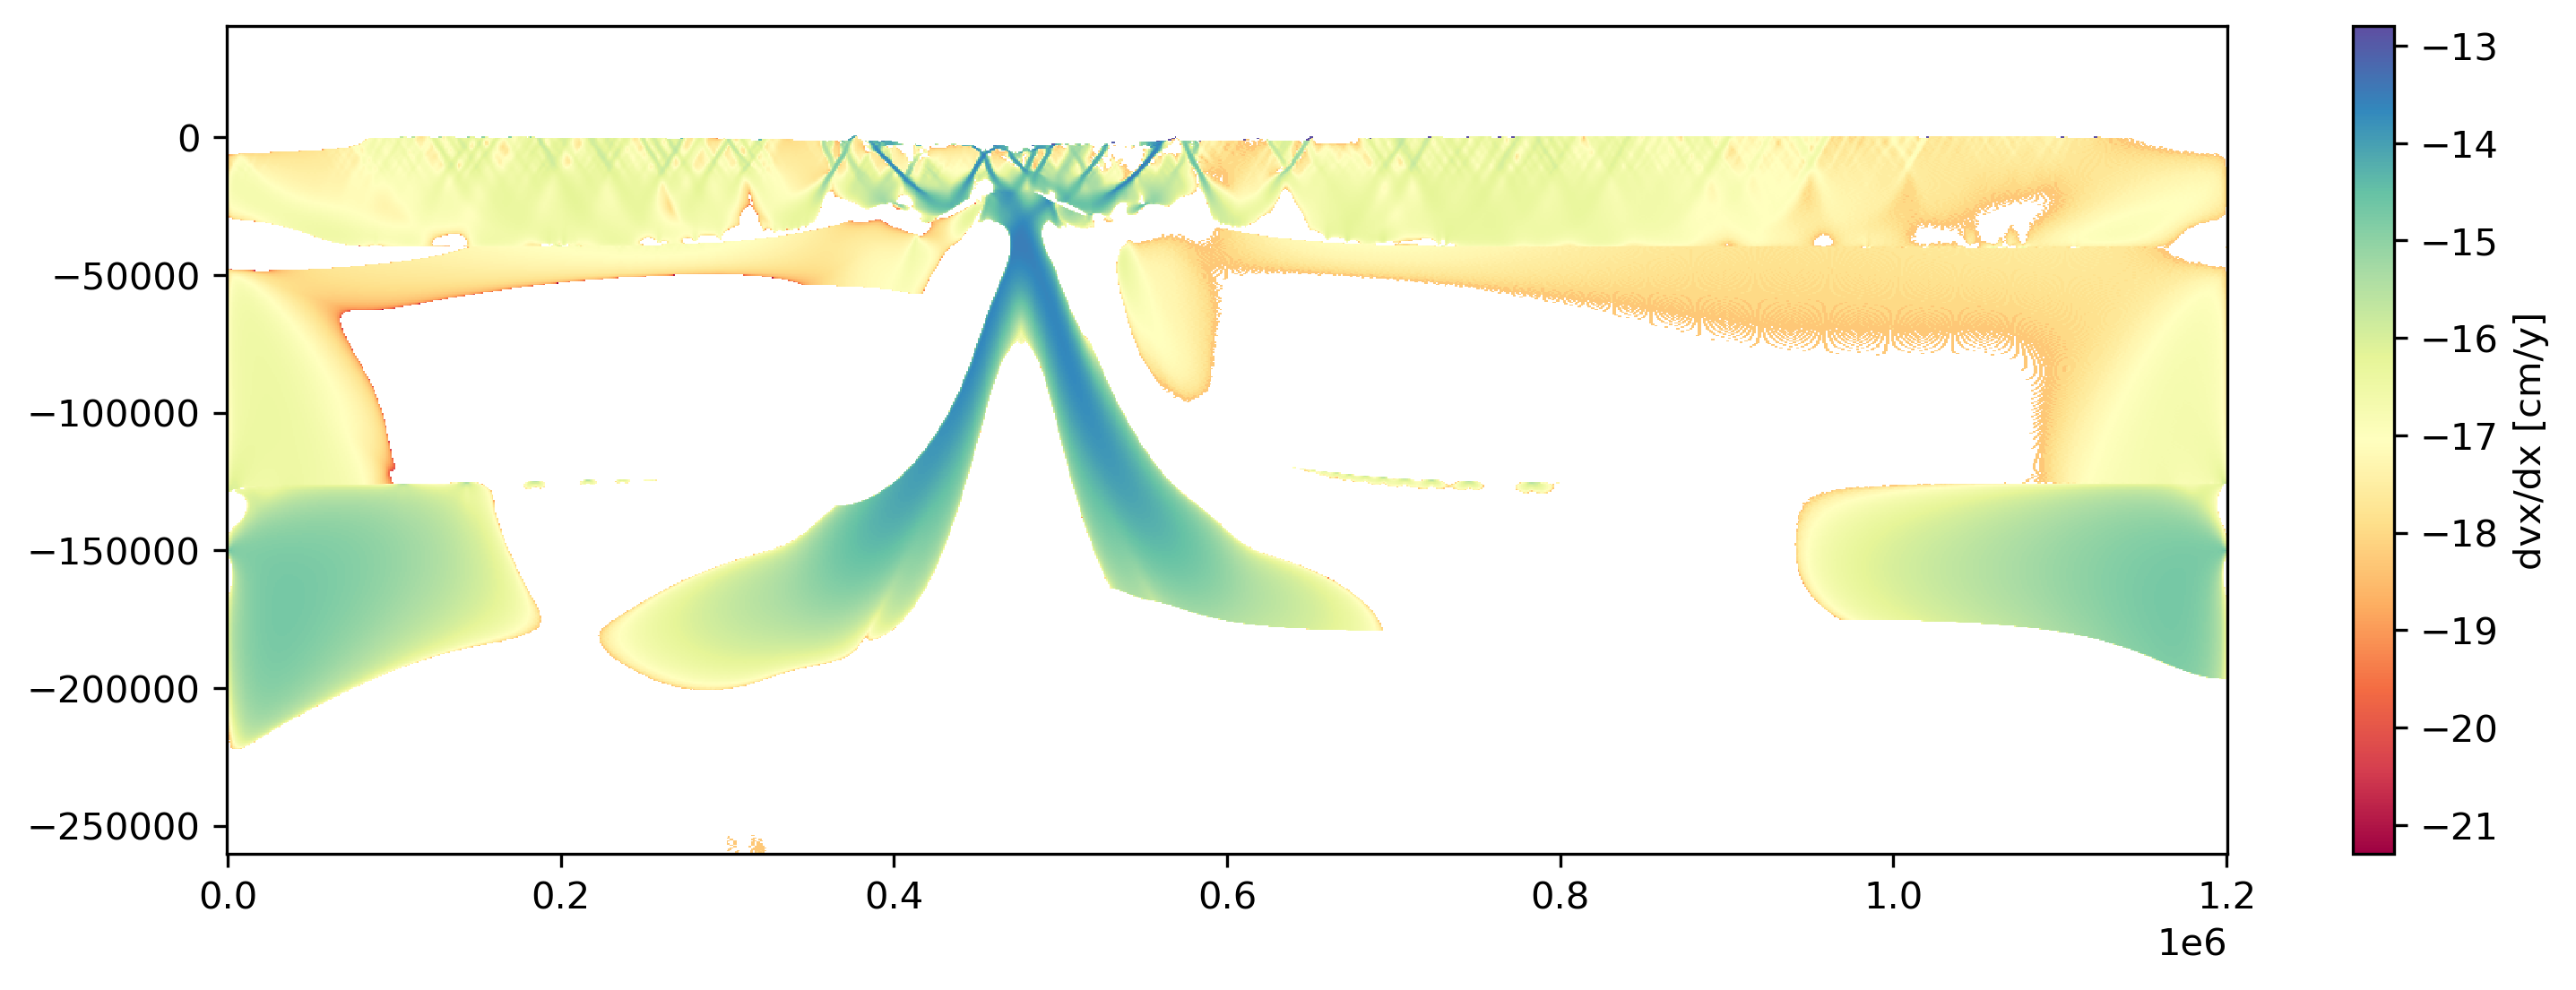

In [59]:
dvx_dx = mesh['vx'].differentiate('x', edge_order=1)

plt.figure(figsize=(12,4),dpi=300)

plt.pcolormesh(dvx_dx.x,dvx_dx.z, np.log10(dvx_dx), cmap='Spectral')
plt.colorbar(label='dvx/dx [cm/y]')


/home/jobueno/anaconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)
/home/jobueno/anaconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


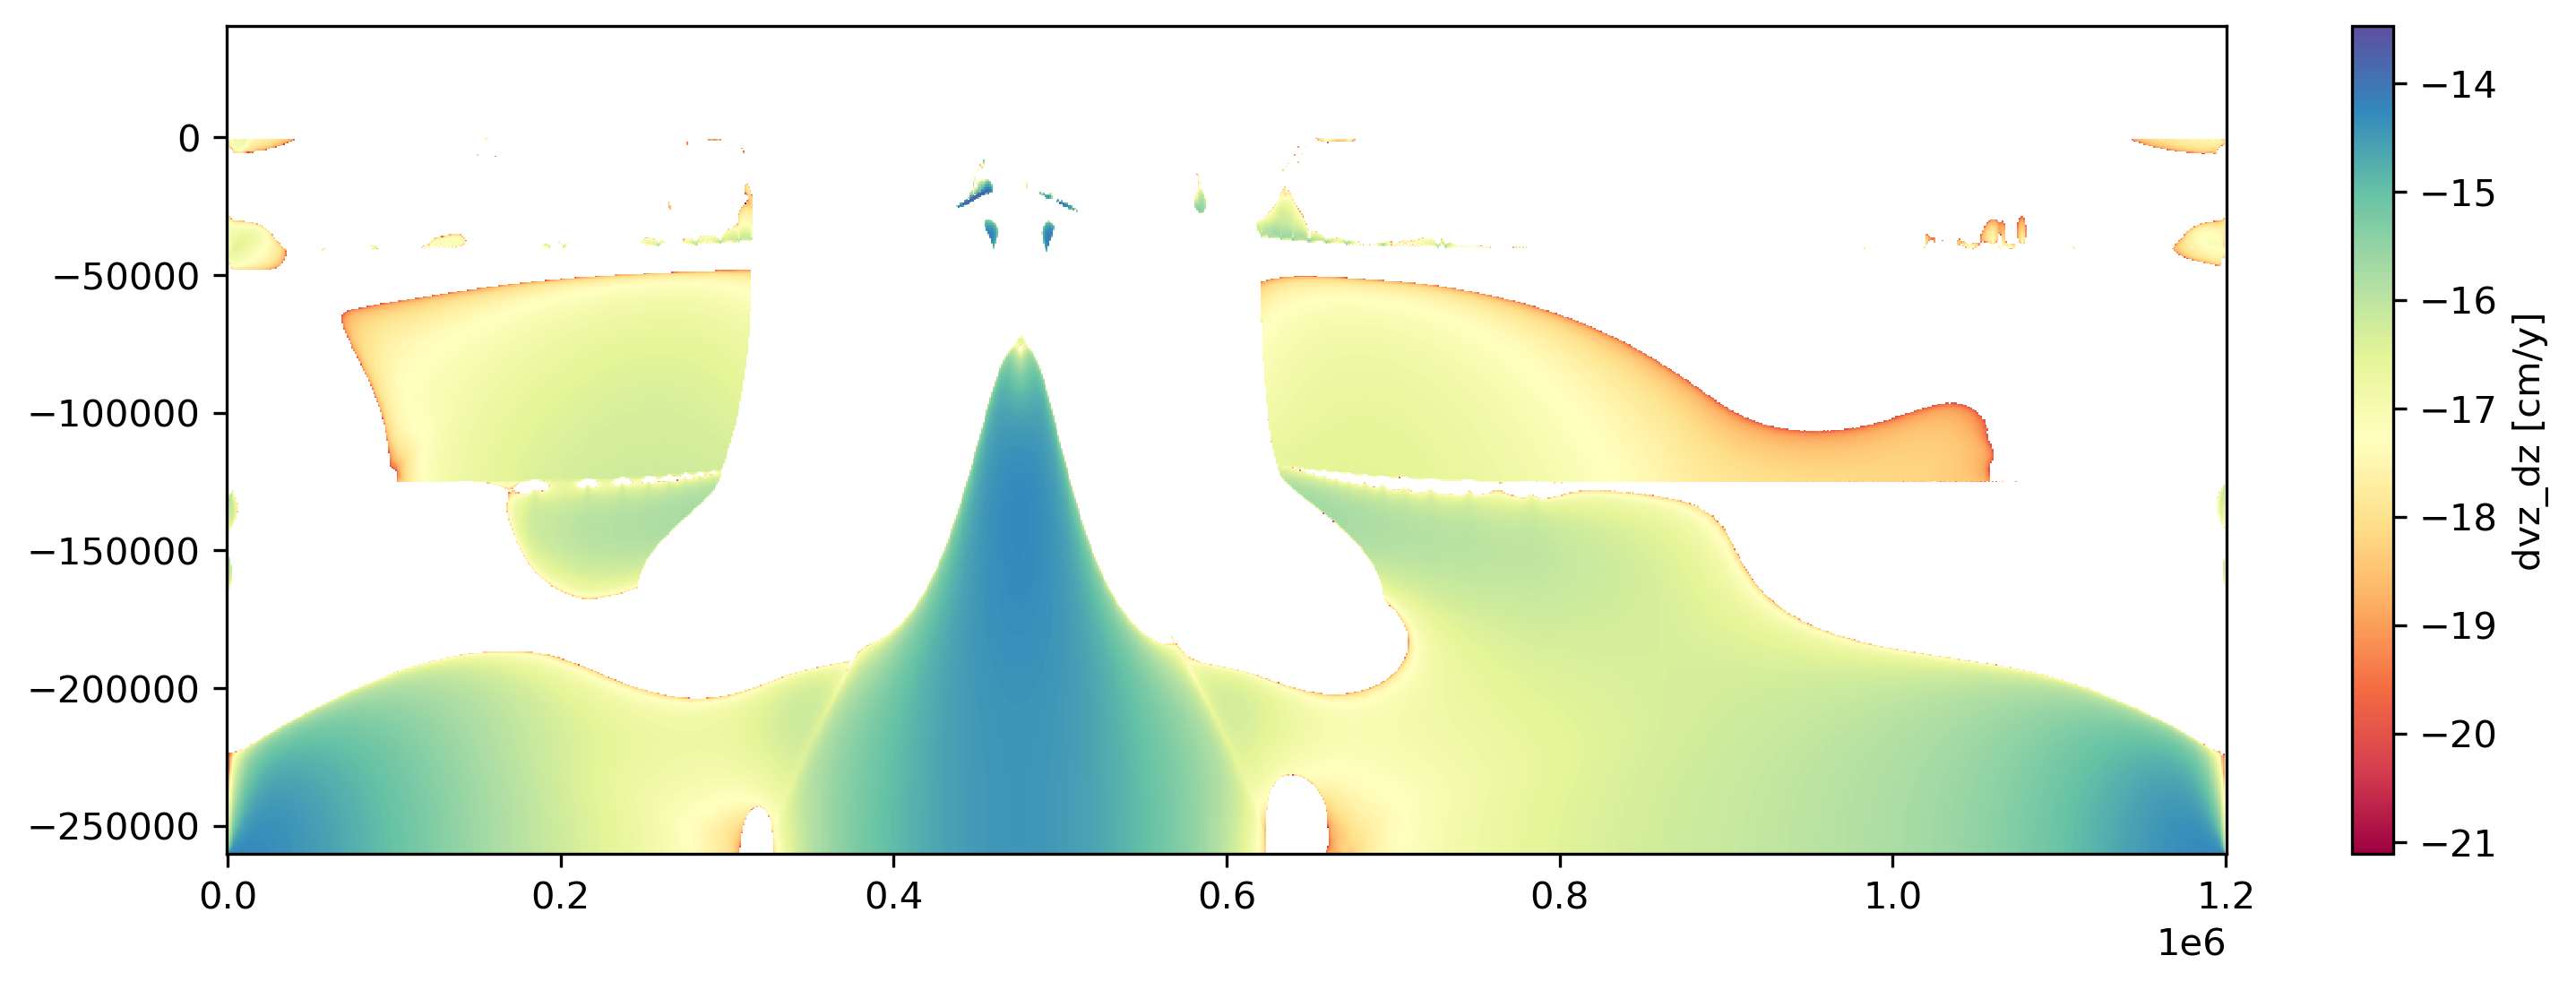

In [58]:
dvz_dz = mesh['vy'].differentiate('z', edge_order=1)

plt.figure(figsize=(12,4),dpi=300)

plt.pcolormesh(dvz_dz.x,dvz_dz.z, np.log10(dvz_dz), cmap='Spectral')
plt.colorbar(label='dvz_dz [cm/y]')


## Particles manipulation

In [64]:
scen.selectParticles_bytimerange([0,20],
                                 select_original=True, replace_original=False, 
                                 selection_name='seltime_0-20')
display(scen.DTree)

<xarray.DataTree>
Group: /
│   Attributes:
│       name:     CS15
│       xlimits:  [0.0, 1200000.0]
│       zlimits:  [0.0, 300000.0]
│       tlimits:  [0, 70]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 555, z: 601, x: 1201)
│   │       Coordinates:
│   │         * time         (time) float32 2kB 0.0 0.2117 0.4234 ... 69.71 69.82 69.92
│   │         * z            (z) float32 2kB -2.6e+05 -2.595e+05 ... 3.95e+04 4e+04
│   │         * x            (x) float32 5kB 0.0 1e+03 2e+03 ... 1.198e+06 1.199e+06 1.2e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           viscosity    (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           vx           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           vy           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           strain       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 555, z: 3001, x: 6001)
│           Coordinates:
│             * time       (time) float32 2kB 0.0 0.2117 0.4234 0.635 ... 69.71 69.82 69.92
│             * z          (z) float32 12kB -2.6e+05 -2.599e+05 ... 3.99e+04 4e+04
│             * x          (x) float32 24kB 0.0 200.0 400.0 ... 1.2e+06 1.2e+06 1.2e+06
│           Data variables:
│               lithology  (time, z, x) int8 10GB dask.array<chunksize=(123, 645, 1287), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 555, x: 60001)
│           Coordinates:
│             * time     (time) float32 2kB 0.0 0.2117 0.4234 0.635 ... 69.71 69.82 69.92
│             * x        (x) float32 240kB 0.0 20.0 40.0 60.0 ... 1.2e+06 1.2e+06 1.2e+06
│           Data variables:
│               surface  (time, x) float32 133MB dask.array<chunksize=(510, 50005), meta=np.ndarray>
└── Group: /particles
    ├── Group: /particles/original
    │       Dimensions:  (id: 336537, time: 555)
    │       Coordinates:
    │         * id       (id) int64 3MB 10007 10008 10010 ... 66013602 66016120 66016121
    │         * time     (time) float64 4kB 0.0 0.2117 0.4234 0.6351 ... 69.71 69.81 69.92
    │       Data variables:
    │           x        (id, time) float64 1GB dask.array<chunksize=(192308, 76), meta=np.ndarray>
    │           z        (id, time) float64 1GB dask.array<chunksize=(192308, 76), meta=np.ndarray>
    │           layer    (id, time) float32 747MB dask.array<chunksize=(168270, 152), meta=np.ndarray>
    │       Attributes:
    │           description:         particle trajectories
    │           reference timestep:  69.286myr (13700)
    │           selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    │           disclaimers:         some particles can change its layer over time (sedim...
    │           weak seed:           2
    ├── Group: /particles/seltime_20-25
    │       Dimensions:  (id: 607, time: 555)
    │       Coordinates:
    │         * id       (id) int64 5kB 64012300 64012301 64012302 ... 63012849 63012853
    │         * time     (time) float64 4kB 0.0 0.2117 0.4234 0.6351 ... 69.71 69.81 69.92
    │       Data variables:
    │           x        (id, time) float64 3MB dask.array<chunksi

In [62]:
scentsel = scen.DTree.sel(time=25,method='nearest').sel(x=slice(0e3,1200e3))

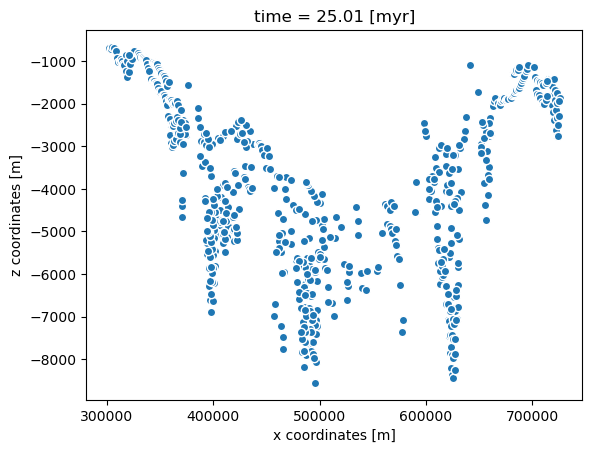

In [63]:
scentsel.particles['seltime_0-20'].ds.plot.scatter(x='x',y='z',cmap='viridis')
plt.show()